In [1]:
!pip install SimpleITK monai tqdm matplotlib seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 59.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import SimpleITK as sitk

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR       = '/content/drive/MyDrive/LUNA16_Project'
ANNOTATIONS_CSV = os.path.join(BASE_DIR, 'annotations.csv')
CANDIDATES_CSV  = os.path.join(BASE_DIR, 'candidates.csv')

# Discover all .mhd scan files across all 10 subsets
mhd_files = []
for i in range(10):
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', '*.mhd'))
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', f'subset{i}', '*.mhd'))
mhd_files = sorted(set(mhd_files))

print(f'MHD scan files found : {len(mhd_files)}')
print(f'annotations.csv      : {os.path.exists(ANNOTATIONS_CSV)}')
print(f'candidates.csv       : {os.path.exists(CANDIDATES_CSV)}')

MHD scan files found : 888
annotations.csv      : True
candidates.csv       : True


## 1. Load and Inspect CSV Files

In [4]:
df_annot = pd.read_csv(ANNOTATIONS_CSV)
df_cand  = pd.read_csv(CANDIDATES_CSV)

print('=' * 55)
print('  annotations.csv  —  confirmed nodule ground truth')
print('=' * 55)
print(f'  Rows              : {len(df_annot):,}')
print(f'  Unique patients   : {df_annot["seriesuid"].nunique():,}')
print(f'  Columns           : {list(df_annot.columns)}')

print()
print('=' * 55)
print('  candidates.csv  —  all candidate locations')
print('=' * 55)
print(f'  Total rows        : {len(df_cand):,}')
print(f'  Positives (class=1): {(df_cand["class"]==1).sum():,}')
print(f'  Negatives (class=0): {(df_cand["class"]==0).sum():,}')
print(f'  Unique patients   : {df_cand["seriesuid"].nunique():,}')
print(f'  Imbalance ratio   : {(df_cand["class"]==0).sum() / (df_cand["class"]==1).sum():.0f}:1  (neg:pos)')
print(f'  Columns           : {list(df_cand.columns)}')

  annotations.csv  —  confirmed nodule ground truth
  Rows              : 1,186
  Unique patients   : 601
  Columns           : ['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']

  candidates.csv  —  all candidate locations
  Total rows        : 551,065
  Positives (class=1): 1,351
  Negatives (class=0): 549,714
  Unique patients   : 888
  Imbalance ratio   : 407:1  (neg:pos)
  Columns           : ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']


In [5]:
print('annotations.csv — sample rows')
display(df_annot.head(5))

print('\ncandidates.csv — sample rows')
display(df_cand.head(5))

annotations.csv — sample rows


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150



candidates.csv — sample rows


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [6]:
print('Nodule diameter statistics (mm):')
display(df_annot['diameter_mm'].describe().round(3).to_frame())

Nodule diameter statistics (mm):


,diameter_mm
count,1186.000
mean,8.307
std,4.762
min,3.253
25%,5.107
50%,6.434
75%,9.696
max,32.270


## 2. Dataset Statistics Visualizations

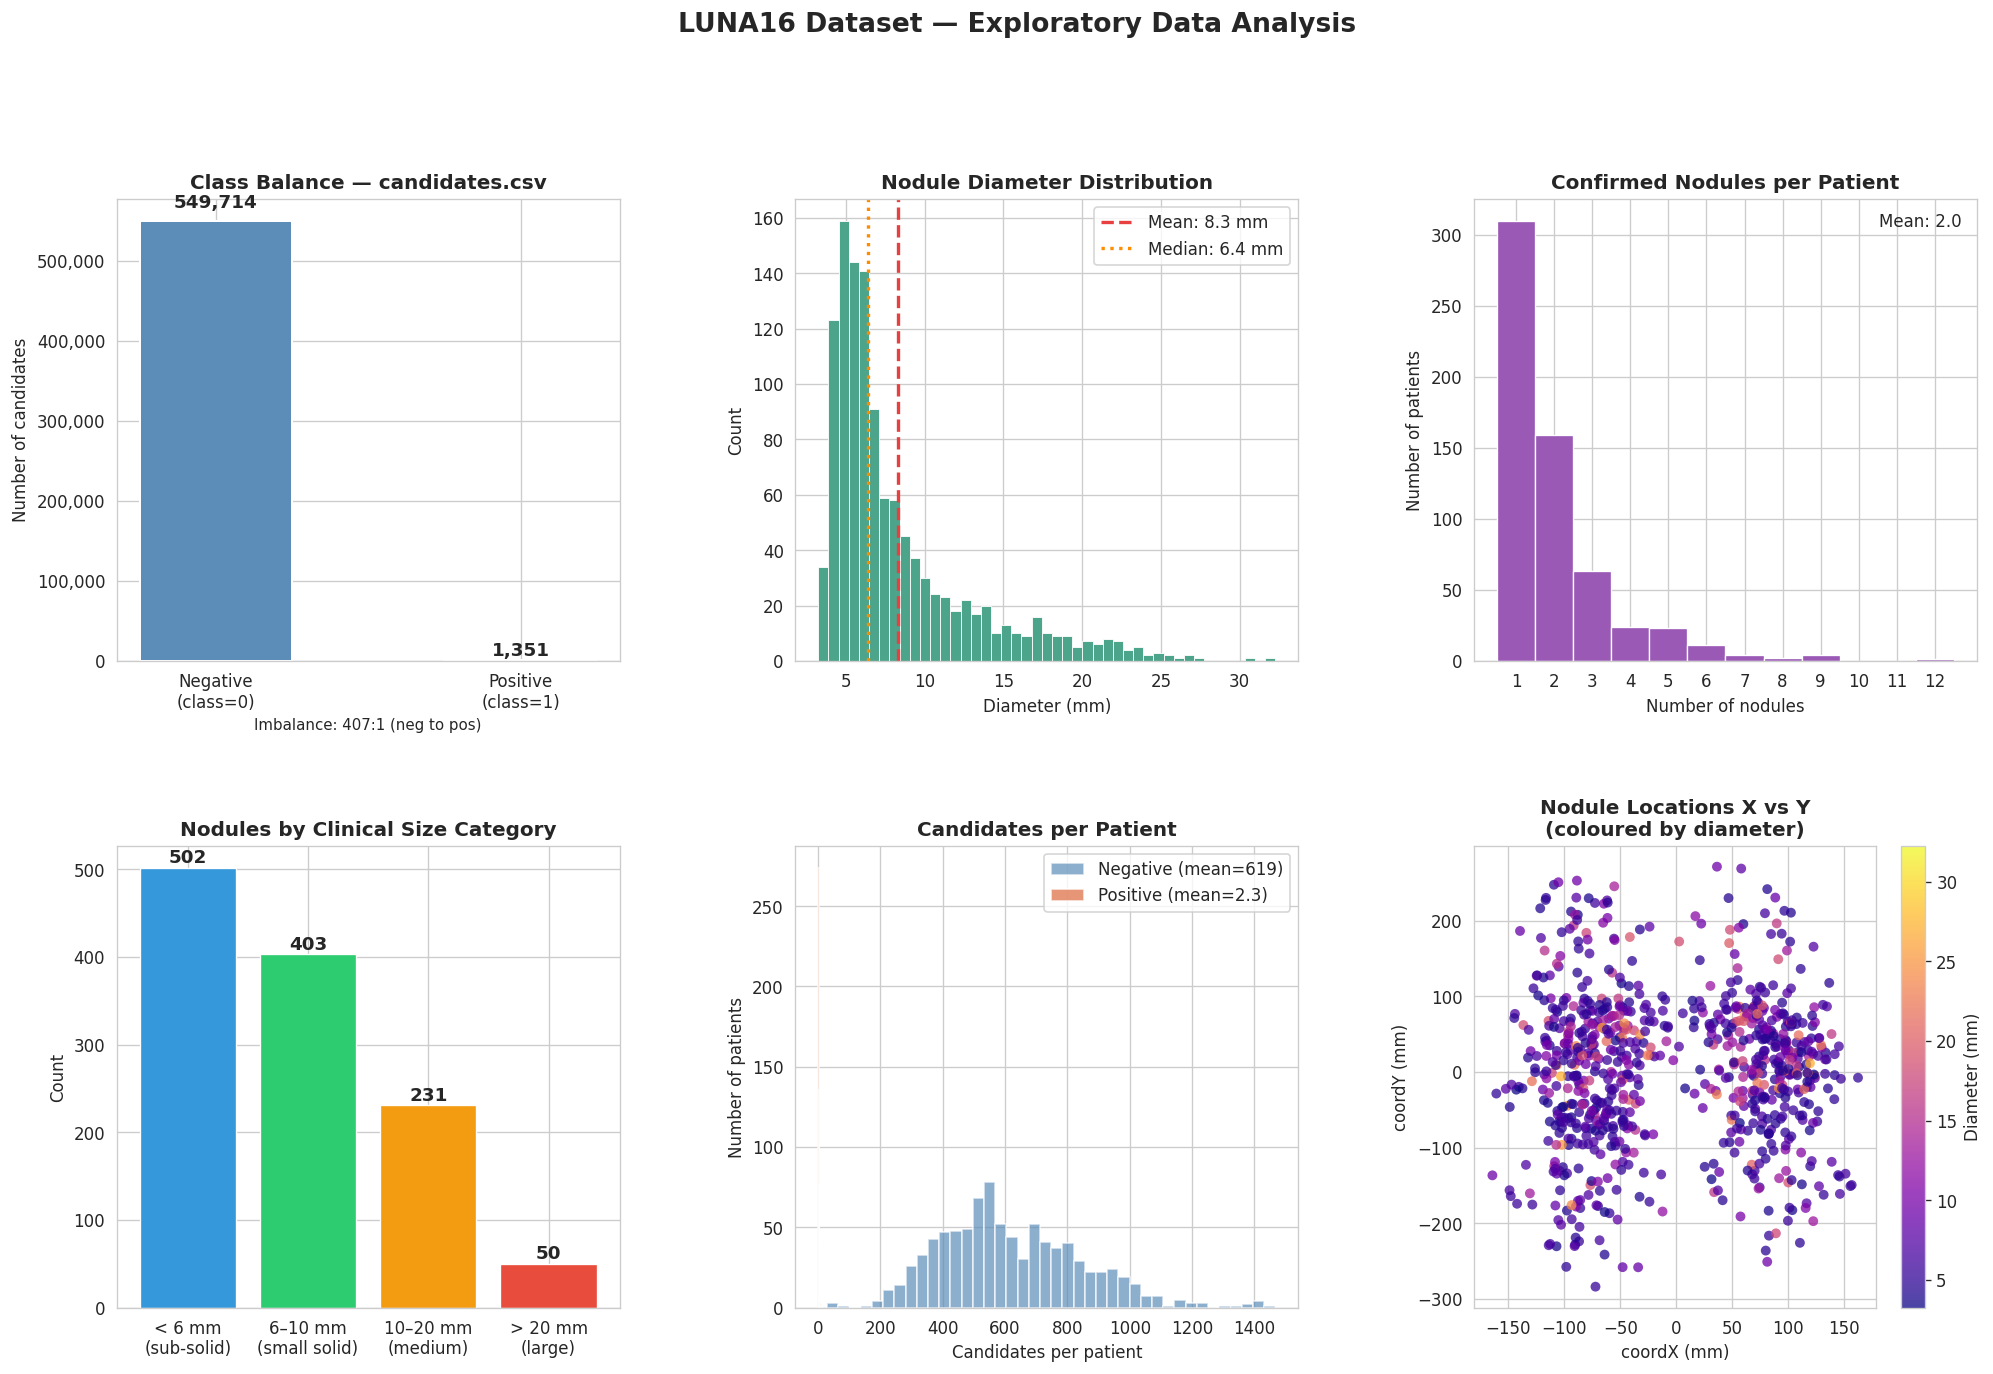

Saved → eda_statistics.png


In [7]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('LUNA16 Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Class Balance ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df_cand['class'].value_counts().sort_index()
bars = ax1.bar(['Negative\n(class=0)', 'Positive\n(class=1)'],
               counts.values, color=['#5B8DB8', '#E07B54'],
               edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Class Balance — candidates.csv', fontweight='bold')
ax1.set_ylabel('Number of candidates')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ratio = counts[0] / counts[1]
ax1.set_xlabel(f'Imbalance: {ratio:.0f}:1 (neg to pos)', fontsize=9)

# ── Plot 2: Nodule Diameter Distribution ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_annot['diameter_mm'], bins=45, color='#4CA58A',
         edgecolor='white', linewidth=0.5)
ax2.axvline(df_annot['diameter_mm'].mean(), color='#E84040', linestyle='--',
            linewidth=2, label=f'Mean: {df_annot["diameter_mm"].mean():.1f} mm')
ax2.axvline(df_annot['diameter_mm'].median(), color='#FF8C00', linestyle=':',
            linewidth=2, label=f'Median: {df_annot["diameter_mm"].median():.1f} mm')
ax2.set_title('Nodule Diameter Distribution', fontweight='bold')
ax2.set_xlabel('Diameter (mm)')
ax2.set_ylabel('Count')
ax2.legend()

# ── Plot 3: Nodules Per Patient ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
npp = df_annot.groupby('seriesuid').size()
ax3.hist(npp.values, bins=range(1, npp.max() + 2), align='left',
         color='#9B59B6', edgecolor='white', linewidth=0.8)
ax3.set_title('Confirmed Nodules per Patient', fontweight='bold')
ax3.set_xlabel('Number of nodules')
ax3.set_ylabel('Number of patients')
ax3.set_xticks(range(1, npp.max() + 1))
ax3.text(0.97, 0.97, f'Mean: {npp.mean():.1f}',
         transform=ax3.transAxes, ha='right', va='top', fontsize=10)

# ── Plot 4: Size Category Buckets ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
labels = ['< 6 mm\n(sub-solid)', '6–10 mm\n(small solid)',
          '10–20 mm\n(medium)', '> 20 mm\n(large)']
edges  = [0, 6, 10, 20, df_annot['diameter_mm'].max() + 1]
buckets = pd.cut(df_annot['diameter_mm'], bins=edges,
                  labels=labels).value_counts().reindex(labels)
colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C']
bars4 = ax4.bar(labels, buckets.values, color=colors,
                edgecolor='white', linewidth=0.8)
for bar, val in zip(bars4, buckets.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_title('Nodules by Clinical Size Category', fontweight='bold')
ax4.set_ylabel('Count')

# ── Plot 5: Candidates Per Patient (Pos vs Neg) ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cpp_pos = df_cand[df_cand['class']==1].groupby('seriesuid').size()
cpp_neg = df_cand[df_cand['class']==0].groupby('seriesuid').size()
ax5.hist(cpp_neg.values, bins=40, alpha=0.7, color='#5B8DB8',
         label=f'Negative (mean={cpp_neg.mean():.0f})')
ax5.hist(cpp_pos.values, bins=20, alpha=0.8, color='#E07B54',
         label=f'Positive (mean={cpp_pos.mean():.1f})')
ax5.set_title('Candidates per Patient', fontweight='bold')
ax5.set_xlabel('Candidates per patient')
ax5.set_ylabel('Number of patients')
ax5.legend()

# ── Plot 6: Spatial Scatter (X vs Y colored by size) ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
sample = df_annot.sample(min(len(df_annot), 800), random_state=42)
sc = ax6.scatter(sample['coordX'], sample['coordY'],
                  c=sample['diameter_mm'], cmap='plasma',
                  alpha=0.75, s=35, edgecolors='none')
plt.colorbar(sc, ax=ax6, label='Diameter (mm)')
ax6.set_title('Nodule Locations X vs Y\n(coloured by diameter)', fontweight='bold')
ax6.set_xlabel('coordX (mm)')
ax6.set_ylabel('coordY (mm)')

plt.savefig('eda_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → eda_statistics.png')

In [8]:
# ── Printed summary table ─────────────────────────────────────────────────────
summary = {
    'Total CT scans (MHD files)':         len(mhd_files),
    'Patients with confirmed nodules':     df_annot['seriesuid'].nunique(),
    'Total confirmed nodules':             len(df_annot),
    'Avg nodules per annotated patient':   f"{df_annot.groupby('seriesuid').size().mean():.2f}",
    'Total candidates':                    f"{len(df_cand):,}",
    'Positive candidates':                 f"{(df_cand['class']==1).sum():,}",
    'Negative candidates':                 f"{(df_cand['class']==0).sum():,}",
    'Class imbalance ratio':               f"{(df_cand['class']==0).sum()/(df_cand['class']==1).sum():.0f}:1",
    'Diameter — min (mm)':                 f"{df_annot['diameter_mm'].min():.2f}",
    'Diameter — max (mm)':                 f"{df_annot['diameter_mm'].max():.2f}",
    'Diameter — mean (mm)':                f"{df_annot['diameter_mm'].mean():.2f}",
    'Diameter — median (mm)':              f"{df_annot['diameter_mm'].median():.2f}",
    'Diameter — std (mm)':                 f"{df_annot['diameter_mm'].std():.2f}",
    'Nodules < 6 mm':                      int((df_annot['diameter_mm'] < 6).sum()),
    'Nodules 6–10 mm':                     int(((df_annot['diameter_mm'] >= 6) & (df_annot['diameter_mm'] < 10)).sum()),
    'Nodules 10–20 mm':                    int(((df_annot['diameter_mm'] >= 10) & (df_annot['diameter_mm'] < 20)).sum()),
    'Nodules > 20 mm':                     int((df_annot['diameter_mm'] >= 20).sum()),
}
df_summary = pd.DataFrame({'Metric': summary.keys(), 'Value': summary.values()})
display(df_summary.style.set_caption('LUNA16 Dataset Summary').hide(axis='index'))

Metric,Value
Total CT scans (MHD files),888
Patients with confirmed nodules,601
Total confirmed nodules,1186
Avg nodules per annotated patient,1.97
Total candidates,"551,065"
Positive candidates,"1,351"
Negative candidates,"549,714"
Class imbalance ratio,407:1
Diameter — min (mm),3.25
Diameter — max (mm),32.27


## 3. CT Scan Visualization — Preprocessing Preview

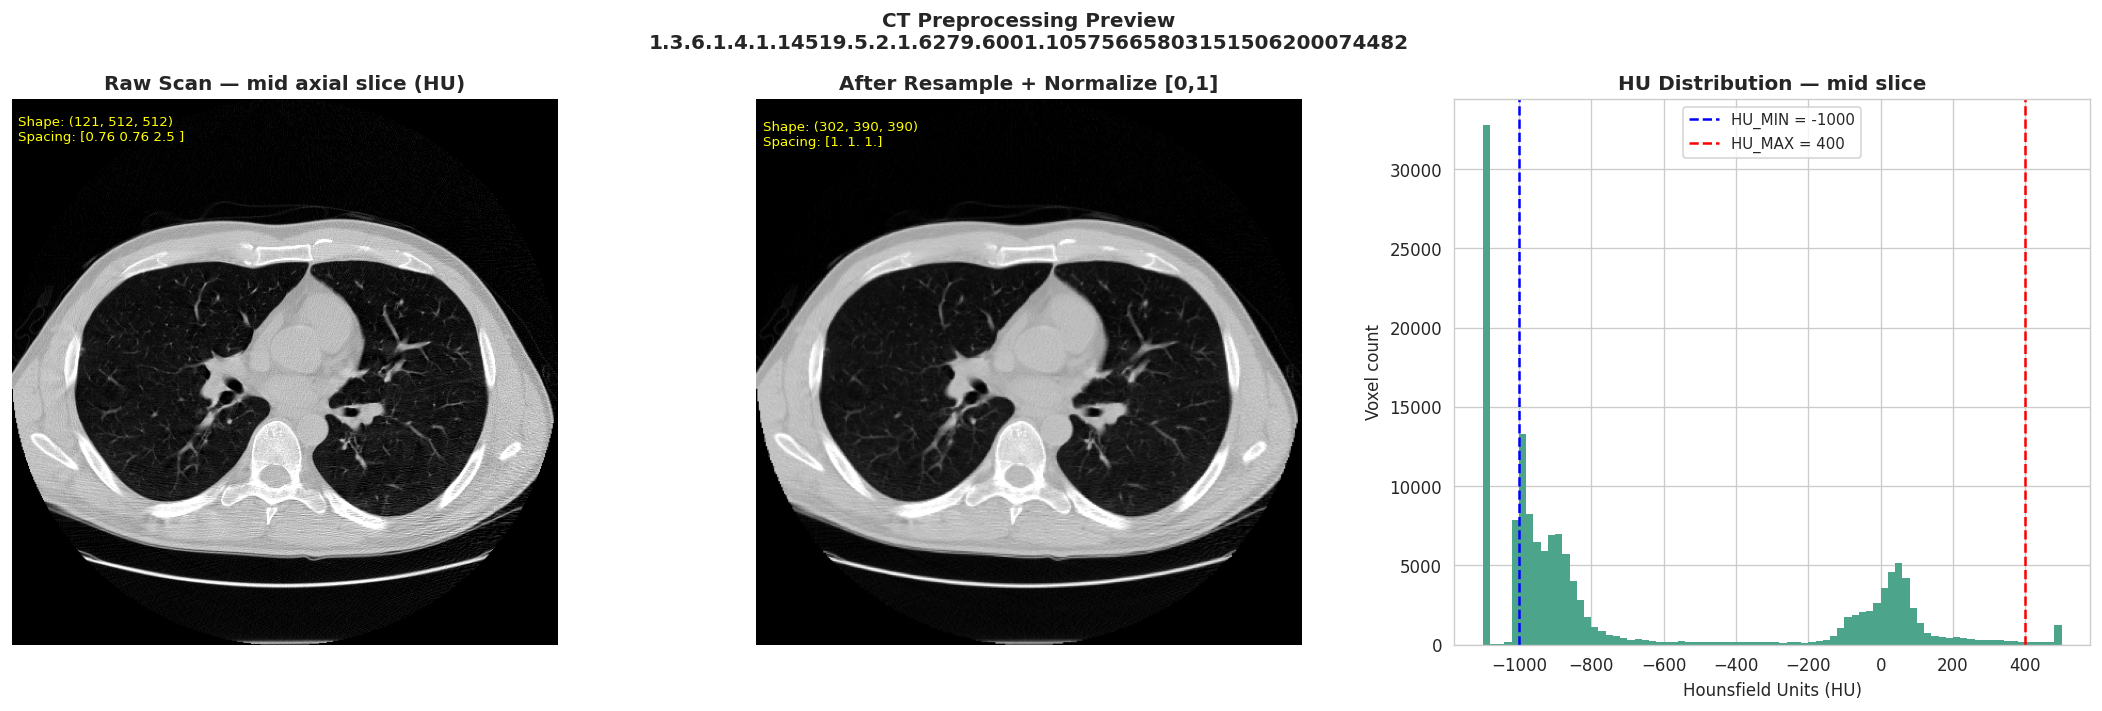

Original spacing : [0.762 0.762 2.5  ] mm
Resampled spacing: [1. 1. 1.] mm
Original size    : (512, 512, 121)
Resampled size   : (390, 390, 302)


In [9]:
def resample_scan(itk_img, new_spacing=[1.0, 1.0, 1.0]):
    orig_spacing = np.array(itk_img.GetSpacing())
    orig_size    = np.array(itk_img.GetSize())
    new_size = [int(round(orig_size[i] * (orig_spacing[i] / new_spacing[i]))) for i in range(3)]
    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(new_spacing)
    r.SetSize(new_size)
    r.SetOutputDirection(itk_img.GetDirection())
    r.SetOutputOrigin(itk_img.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(sitk.sitkLinear)
    return r.Execute(itk_img)


if not mhd_files:
    print('No MHD files found — skipping CT visualization.')
else:
    mhd_path      = mhd_files[0]
    itk_raw       = sitk.ReadImage(mhd_path)
    itk_resampled = resample_scan(itk_raw)
    arr_raw       = sitk.GetArrayFromImage(itk_raw).astype(np.float32)
    arr_res       = sitk.GetArrayFromImage(itk_resampled).astype(np.float32)
    arr_norm      = np.clip(arr_res, -1000.0, 400.0)
    arr_norm      = (arr_norm - (-1000.0)) / (400.0 - (-1000.0))

    mid = arr_norm.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'CT Preprocessing Preview\n{os.path.basename(mhd_path)[:60]}',
                 fontsize=12, fontweight='bold')

    axes[0].imshow(arr_raw[arr_raw.shape[0]//2], cmap='gray', vmin=-1000, vmax=400)
    axes[0].set_title('Raw Scan — mid axial slice (HU)', fontweight='bold')
    axes[0].axis('off')
    axes[0].text(5, 15, f'Shape: {arr_raw.shape}\nSpacing: {np.array(itk_raw.GetSpacing()).round(2)}',
                 color='yellow', fontsize=8, va='top')

    axes[1].imshow(arr_norm[mid], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('After Resample + Normalize [0,1]', fontweight='bold')
    axes[1].axis('off')
    axes[1].text(5, 15, f'Shape: {arr_norm.shape}\nSpacing: {np.array(itk_resampled.GetSpacing())}',
                 color='yellow', fontsize=8, va='top')

    # HU window histogram
    sample_voxels = arr_res[mid].flatten()
    axes[2].hist(np.clip(sample_voxels, -1100, 500), bins=80,
                 color='#4CA58A', edgecolor='none')
    axes[2].axvline(-1000, color='blue', linestyle='--', linewidth=1.5, label='HU_MIN = -1000')
    axes[2].axvline(400,   color='red',  linestyle='--', linewidth=1.5, label='HU_MAX = 400')
    axes[2].set_title('HU Distribution — mid slice', fontweight='bold')
    axes[2].set_xlabel('Hounsfield Units (HU)')
    axes[2].set_ylabel('Voxel count')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('ct_preprocessing_preview.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Original spacing : {np.array(itk_raw.GetSpacing()).round(3)} mm')
    print(f'Resampled spacing: {np.array(itk_resampled.GetSpacing())} mm')
    print(f'Original size    : {itk_raw.GetSize()}')
    print(f'Resampled size   : {itk_resampled.GetSize()}')

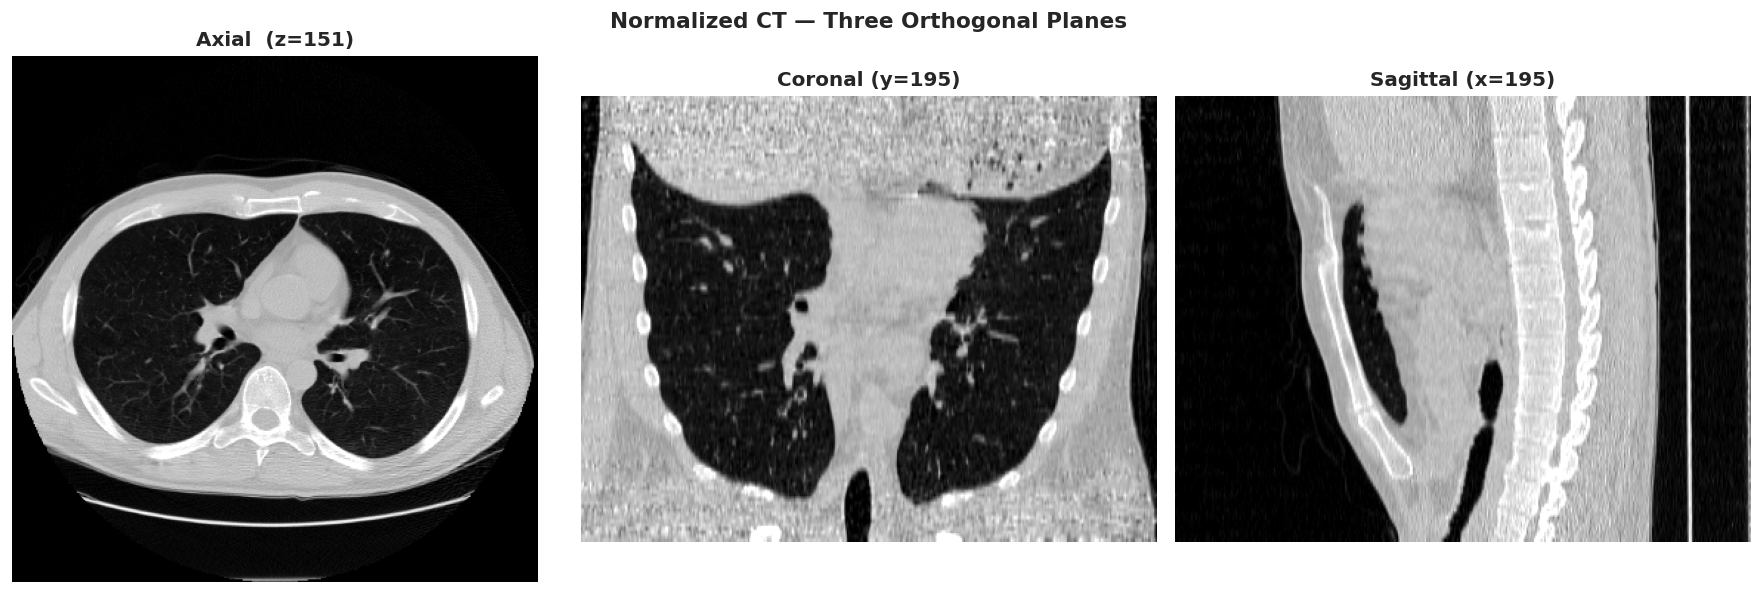

In [ ]:
# ── Three-plane view (axial / coronal / sagittal) ────────────────────────────
if mhd_files:
    Z, Y, X = arr_norm.shape
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Normalized CT — Three Orthogonal Planes', fontweight='bold', fontsize=13)

    axes[0].imshow(arr_norm[Z//2],    cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Axial  (z={Z//2})',    fontweight='bold'); axes[0].axis('off')

    axes[1].imshow(arr_norm[:, Y//2, :], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'Coronal (y={Y//2})',   fontweight='bold'); axes[1].axis('off')

    axes[2].imshow(arr_norm[:, :, X//2], cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'Sagittal (x={X//2})', fontweight='bold'); axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('ct_three_planes.png', dpi=130, bbox_inches='tight')
    plt.show()

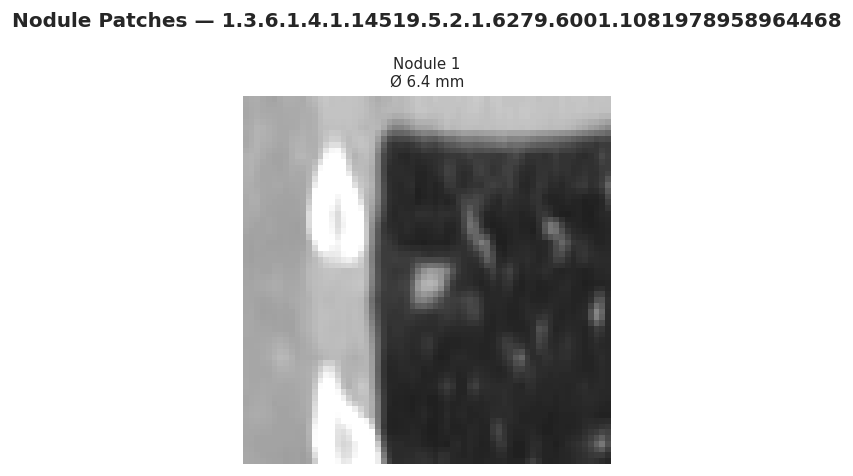

Displayed 1 nodule patches from patient 1.3.6.1.4.1.14519.5.2.1.6279.6001.108197


In [ ]:
# ── Visualize nodule patches for the first annotated scan ────────────────────
if mhd_files:
    # Find a scan that has annotations
    annot_pids = set(df_annot['seriesuid'])
    scan_with_annot = None
    for f in mhd_files:
        pid = os.path.basename(f).replace('.mhd', '')
        if pid in annot_pids:
            scan_with_annot = f
            scan_pid        = pid
            break

    if scan_with_annot:
        itk_s    = resample_scan(sitk.ReadImage(scan_with_annot))
        arr_s    = sitk.GetArrayFromImage(itk_s).astype(np.float32)
        arr_s    = np.clip(arr_s, -1000.0, 400.0)
        arr_s    = (arr_s - (-1000.0)) / (400.0 - (-1000.0))
        origin   = np.array(itk_s.GetOrigin())
        spacing  = np.array(itk_s.GetSpacing())

        nodules = df_annot[df_annot['seriesuid'] == scan_pid]
        n_show  = min(len(nodules), 6)

        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
        if n_show == 1:
            axes = [axes]
        fig.suptitle(f'Nodule Patches — {scan_pid[:50]}', fontweight='bold')

        for i, (_, row) in enumerate(nodules.head(n_show).iterrows()):
            coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
            v = np.round(np.abs(coord - origin) / spacing).astype(int)
            vz, vy, vx = int(v[2]), int(v[1]), int(v[0])

            half = 32
            z1 = max(vz - half, 0); z2 = min(vz + half, arr_s.shape[0])
            y1 = max(vy - half, 0); y2 = min(vy + half, arr_s.shape[1])
            x1 = max(vx - half, 0); x2 = min(vx + half, arr_s.shape[2])

            patch = arr_s[z1:z2, vy, x1:x2]   # mid-nodule axial slice
            axes[i].imshow(patch, cmap='gray', vmin=0, vmax=1)
            axes[i].set_title(f'Nodule {i+1}\nØ {row["diameter_mm"]:.1f} mm', fontsize=9)
            axes[i].axis('off')

        plt.tight_layout()
        plt.savefig('nodule_patches_preview.png', dpi=130, bbox_inches='tight')
        plt.show()
        print(f'Displayed {n_show} nodule patches from patient {scan_pid[:40]}')
    else:
        print('No annotated scan found in mhd_files.')